# TODO:
I. Finish the project !  
1. ~~voting classifier~~
2. ~~comparison~~
3. final test
4. Conclusion

II. Double check the code:
1. Check if all the comments, name of the variables, etc. are in english
2. ~~Harmoniser les modèles:~~
  - ~~pour chaque modèle on affiche l'overfitting~~
  - ~~gérer l'overfitting~~
3. Check the nexts part are similar to the TDs
  - Imbalanced Data
  - PCA (+ vérifier si les ccl sont correctes)
  - ~~Ensemble models~~
4. ~~Check and modify if necessary the "Relevant Metrics" part~~
5. Check and modify the Data Leakage part: maybe we need to say that there isn't any data leakage and that's it

III. Write the full report
- Include the firsts 2 notebooks (F1 and Spotify)  

IV. Video
- Write the script of the video
- If it requires slides then do it
- Record the video
- Edit the video  

V. Deposit the project !

# I. Importation of librairies and dataset

## 1. Librairies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

## 2. Dataset

In [ ]:
df = pd.read_csv('train.csv')

In [ ]:
df.rename(columns={'is_churned': 'is_inactive'}, inplace=True)

# II. Dataset analysis

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   Surname          165034 non-null  object 
 3   CreditScore      165034 non-null  int64  
 4   Geography        165034 non-null  object 
 5   Gender           165034 non-null  object 
 6   Age              165034 non-null  float64
 7   Tenure           165034 non-null  int64  
 8   Balance          165034 non-null  float64
 9   NumOfProducts    165034 non-null  int64  
 10  HasCrCard        165034 non-null  float64
 11  IsActiveMember   165034 non-null  float64
 12  EstimatedSalary  165034 non-null  float64
 13  Exited           165034 non-null  int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 17.6+ MB
None


## 1. Number of columns/rows

In [ ]:
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Shape: (165034, 14)
Rows: 165034, Columns: 14


## 2. Number of values

In [ ]:
# Basic statistics
print(df.describe())

                id    CustomerId    CreditScore            Age         Tenure  \
count  165034.0000  1.650340e+05  165034.000000  165034.000000  165034.000000   
mean    82516.5000  1.569201e+07     656.454373      38.125888       5.020353   
std     47641.3565  7.139782e+04      80.103340       8.867205       2.806159   
min         0.0000  1.556570e+07     350.000000      18.000000       0.000000   
25%     41258.2500  1.563314e+07     597.000000      32.000000       3.000000   
50%     82516.5000  1.569017e+07     659.000000      37.000000       5.000000   
75%    123774.7500  1.575682e+07     710.000000      42.000000       7.000000   
max    165033.0000  1.581569e+07     850.000000      92.000000      10.000000   

             Balance  NumOfProducts      HasCrCard  IsActiveMember  \
count  165034.000000  165034.000000  165034.000000   165034.000000   
mean    55478.086689       1.554455       0.753954        0.497770   
std     62817.663278       0.547154       0.430707        0.

In [ ]:
# Categorical variables summary
categorical_cols = ['Surname', 'Geography', 'Gender']
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


Surname:
Surname
Hsia         2456
T'ien        2282
Hs?          1611
Maclean      1577
Kao          1577
             ... 
Topp            1
Blacklock       1
McDaniels       1
McMinn          1
Elkins          1
Name: count, Length: 2797, dtype: int64

Geography:
Geography
France     94215
Spain      36213
Germany    34606
Name: count, dtype: int64

Gender:
Gender
Male      93150
Female    71884
Name: count, dtype: int64


## 3. Variables definition

In [ ]:
print(df.dtypes)

id                   int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                float64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard          float64
IsActiveMember     float64
EstimatedSalary    float64
Exited               int64
dtype: object


In [ ]:
print(df.head())

   id  CustomerId         Surname  CreditScore Geography Gender   Age  Tenure  \
0   0    15674932  Okwudilichukwu          668    France   Male  33.0       3   
1   1    15749177   Okwudiliolisa          627    France   Male  33.0       1   
2   2    15694510           Hsueh          678    France   Male  40.0      10   
3   3    15741417             Kao          581    France   Male  34.0       2   
4   4    15766172       Chiemenam          716     Spain   Male  33.0       5   

     Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  \
0       0.00              2        1.0             0.0        181449.97   
1       0.00              2        1.0             1.0         49503.50   
2       0.00              2        1.0             0.0        184866.69   
3  148882.54              1        1.0             1.0         84560.88   
4       0.00              2        1.0             1.0         15068.83   

   Exited  
0       0  
1       0  
2       0  
3       0  
4 

## 4. Quality

In [ ]:
# Data range and potential outliers
numeric_cols = ['id', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
for col in numeric_cols:
    print(f"\n{col}:")
    print(f"  Min: {df[col].min()}, Max: {df[col].max()}")
    print(f"  Mean: {df[col].mean():.2f}, Median: {df[col].median()}")

    # Check for potential outliers using IQR method
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"  Potential outliers: {len(outliers)}")


id:
  Min: 0, Max: 165033
  Mean: 82516.50, Median: 82516.5
  Potential outliers: 0

CustomerId:
  Min: 15565701, Max: 15815690
  Mean: 15692005.02, Median: 15690169.0
  Potential outliers: 0

CreditScore:
  Min: 350, Max: 850
  Mean: 656.45, Median: 659.0
  Potential outliers: 253

Age:
  Min: 18.0, Max: 92.0
  Mean: 38.13, Median: 37.0
  Potential outliers: 6394

Tenure:
  Min: 0, Max: 10
  Mean: 5.02, Median: 5.0
  Potential outliers: 0

Balance:
  Min: 0.0, Max: 250898.09
  Mean: 55478.09, Median: 0.0
  Potential outliers: 0

NumOfProducts:
  Min: 1, Max: 4
  Mean: 1.55, Median: 2.0
  Potential outliers: 475

HasCrCard:
  Min: 0.0, Max: 1.0
  Mean: 0.75, Median: 1.0
  Potential outliers: 40606

IsActiveMember:
  Min: 0.0, Max: 1.0
  Mean: 0.50, Median: 0.0
  Potential outliers: 0

EstimatedSalary:
  Min: 11.58, Max: 199992.48
  Mean: 112574.82, Median: 117948.0
  Potential outliers: 0

Exited:
  Min: 0, Max: 1
  Mean: 0.21, Median: 0.0
  Potential outliers: 34921


In [ ]:
# # Data range and potential outliers
# numeric_cols = ['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
# for col in numeric_cols:
#     print(f"\n{col}:")
#     print(f"  Min: {df[col].min()}, Max: {df[col].max()}")
#     print(f"  Mean: {df[col].mean():.2f}, Median: {df[col].median()}")

#     # Check for potential outliers using IQR method
#     Q1 = df[col].quantile(0.25)
#     Q3 = df[col].quantile(0.75)
#     IQR = Q3 - Q1
#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR
#     outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
#     print(f"  Potential outliers: {len(outliers)}")

## 5. Visualization

In [ ]:
plt.style.use('default')
sns.set_palette("husl")

### i. Variables distributions

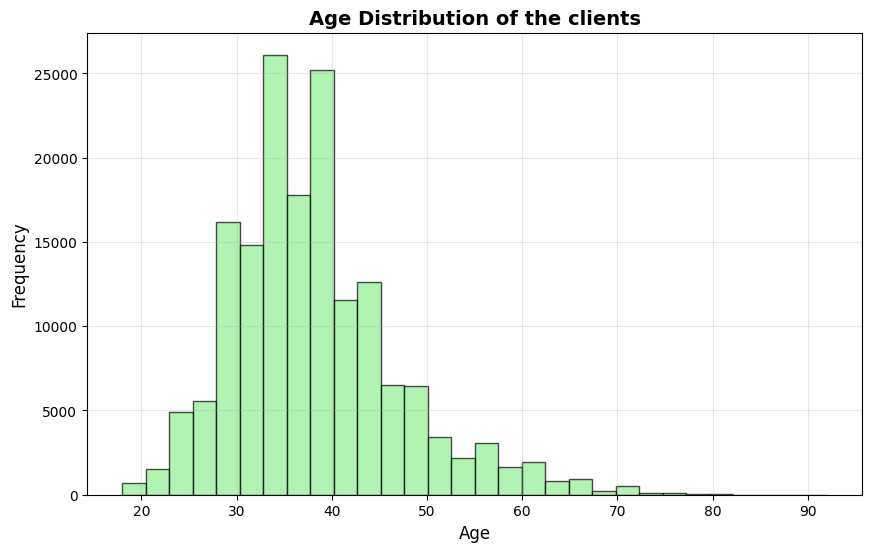

Age statistics:
Min: 18.0, Max: 92.0, Mean: 38.1, Median: 37.0


In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df['Age'], bins=30, color='lightgreen', alpha=0.7, edgecolor='black')
plt.title('Age Distribution of the clients', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

print(f"Age statistics:\nMin: {df['Age'].min()}, Max: {df['Age'].max()}, Mean: {df['Age'].mean():.1f}, Median: {df['Age'].median()}")

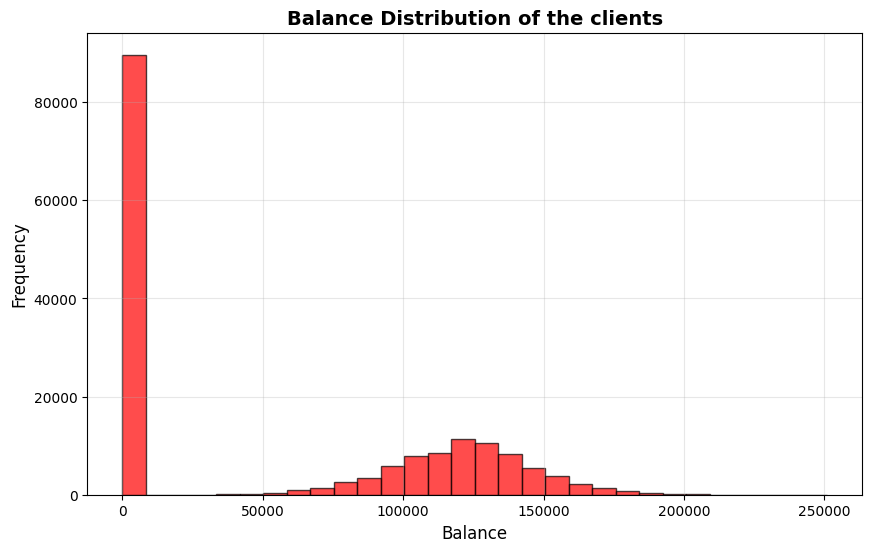

Balance statistics:
Min: 0.0, Max: 250898.09, Mean: 55478.1, Median: 0.0


In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df['Balance'], bins=30, color='red', alpha=0.7, edgecolor='black')
plt.title('Balance Distribution of the clients', fontsize=14, fontweight='bold')
plt.xlabel('Balance', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

print(f"Balance statistics:\nMin: {df['Balance'].min()}, Max: {df['Balance'].max()}, Mean: {df['Balance'].mean():.1f}, Median: {df['Balance'].median()}")

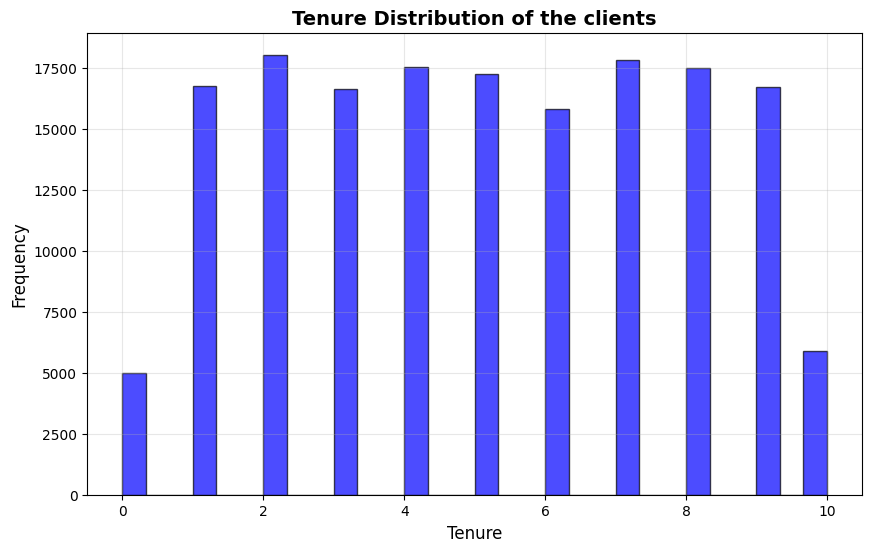

Tenure statistics:
Min: 0, Max: 10, Mean: 5.0, Median: 5.0


In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df['Tenure'], bins=30, color='blue', alpha=0.7, edgecolor='black')
plt.title('Tenure Distribution of the clients', fontsize=14, fontweight='bold')
plt.xlabel('Tenure', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

print(f"Tenure statistics:\nMin: {df['Tenure'].min()}, Max: {df['Tenure'].max()}, Mean: {df['Tenure'].mean():.1f}, Median: {df['Tenure'].median()}")

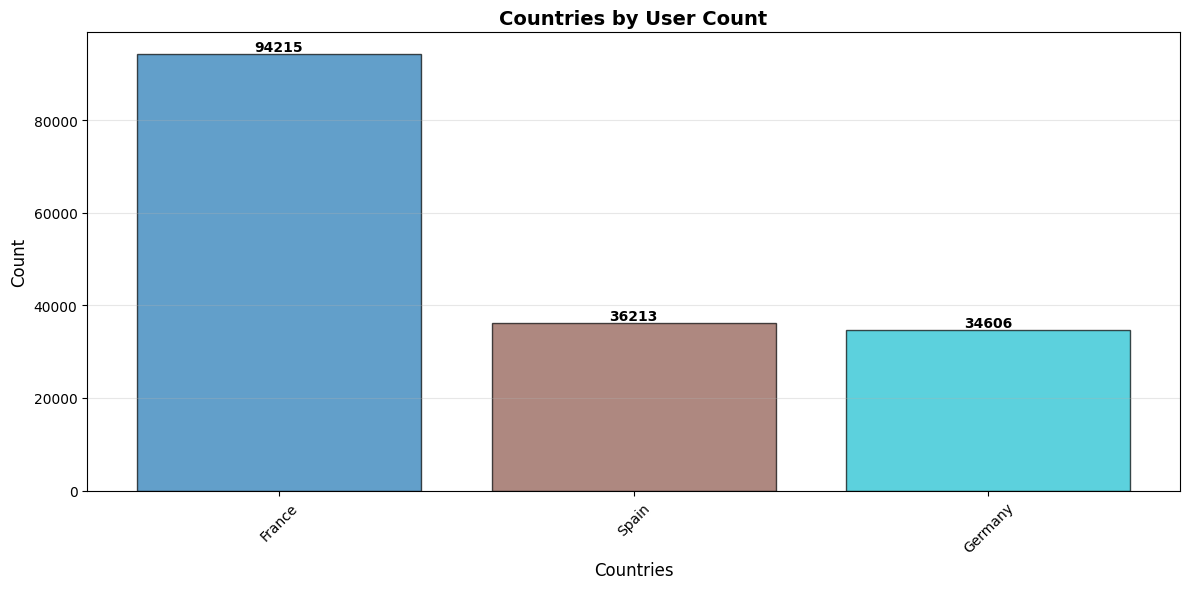

In [ ]:
plt.figure(figsize=(12, 6))
country_counts = df['Geography'].value_counts()
colors = plt.cm.tab10(np.linspace(0, 1, len(country_counts)))
plt.bar(country_counts.index, country_counts.values, color=colors, alpha=0.7, edgecolor='black')
plt.title('Countries by User Count', fontsize=14, fontweight='bold')
plt.xlabel('Countries', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
for i, v in enumerate(country_counts.values):
    plt.text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

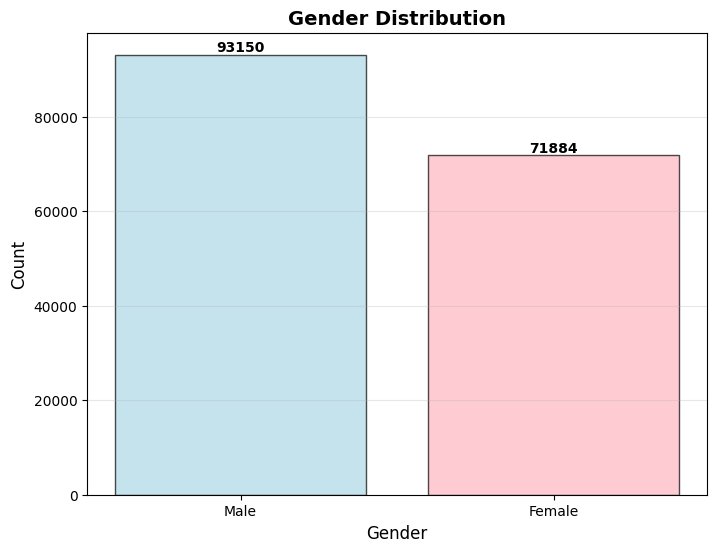

In [ ]:
plt.figure(figsize=(8, 6))
gender_counts = df['Gender'].value_counts()
colors = ['lightblue', 'lightpink', 'lightgray']
plt.bar(gender_counts.index, gender_counts.values, color=colors, alpha=0.7, edgecolor='black')
plt.title('Gender Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count', fontsize=12)
for i, v in enumerate(gender_counts.values):
    plt.text(i, v + 10, str(v), ha='center', va='bottom', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.show()

### ii. exited (Target Variable) distribution by different variables

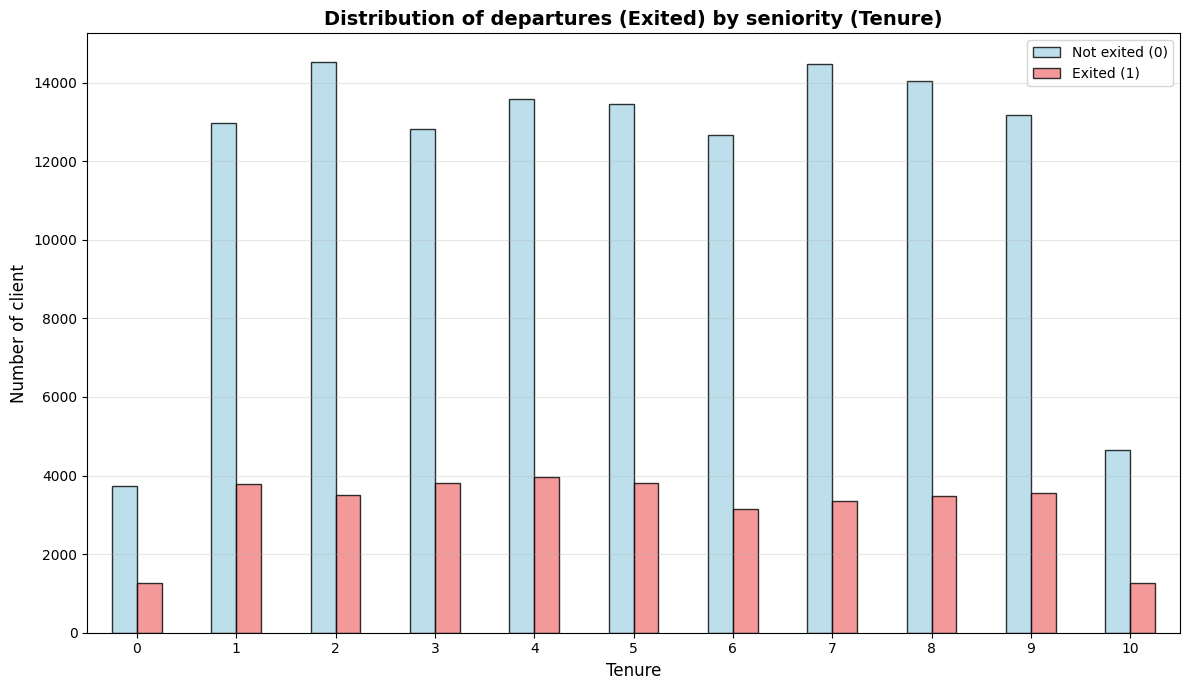

In [ ]:
tenure_churn_crosstab = pd.crosstab(df['Tenure'], df['Exited'])

tenure_churn_crosstab.plot(
    kind='bar',
    color=['lightblue', 'lightcoral'],
    alpha=0.8,
    edgecolor='black',
    figsize=(12, 7)
)

plt.title('Distribution of departures (Exited) by seniority (Tenure)', fontsize=14, fontweight='bold')
plt.xlabel('Tenure', fontsize=12)
plt.ylabel('Number of client', fontsize=12)

plt.legend(['Not exited (0)', 'Exited (1)'])
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

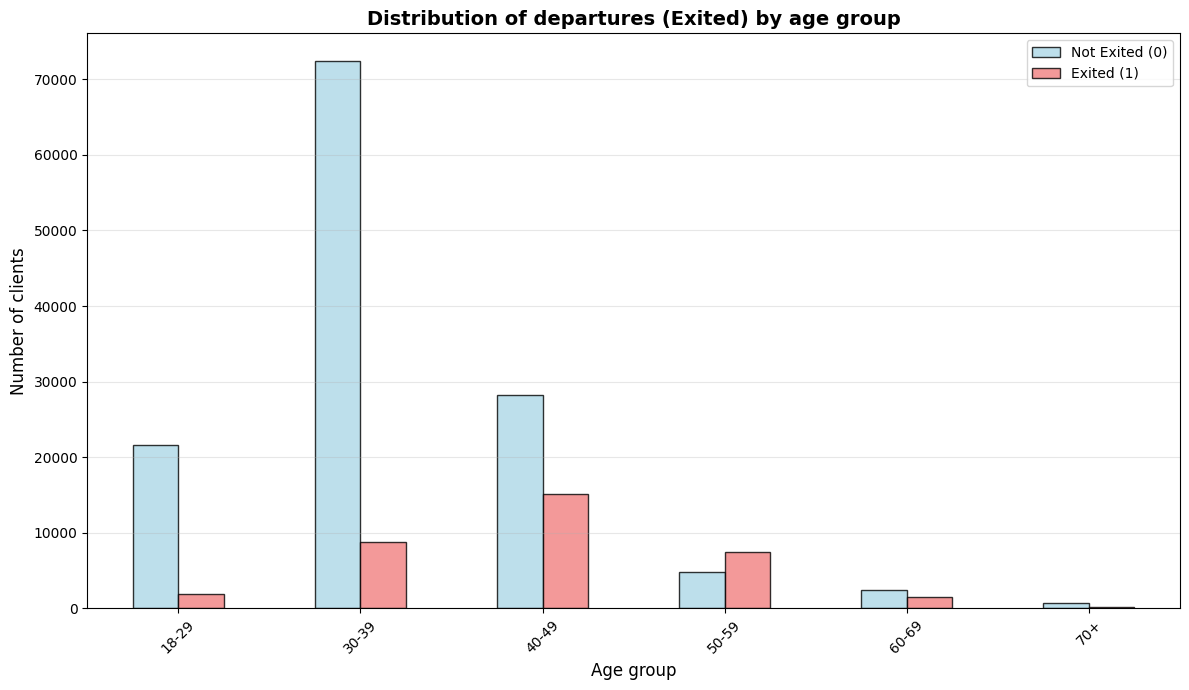

In [ ]:
bins = [18, 30, 40, 50, 60, 70, 100]
labels = ['18-29', '30-39', '40-49', '50-59', '60-69', '70+']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

age_churn_crosstab = pd.crosstab(df['AgeGroup'], df['Exited'])

age_churn_crosstab.plot(
    kind='bar',
    color=['lightblue', 'lightcoral'],
    alpha=0.8,
    edgecolor='black',
    figsize=(12, 7)
)

plt.title('Distribution of departures (Exited) by age group', fontsize=14, fontweight='bold')
plt.xlabel('Age group', fontsize=12)
plt.ylabel('Number of clients', fontsize=12)
plt.legend(['Not Exited (0)', 'Exited (1)'])
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

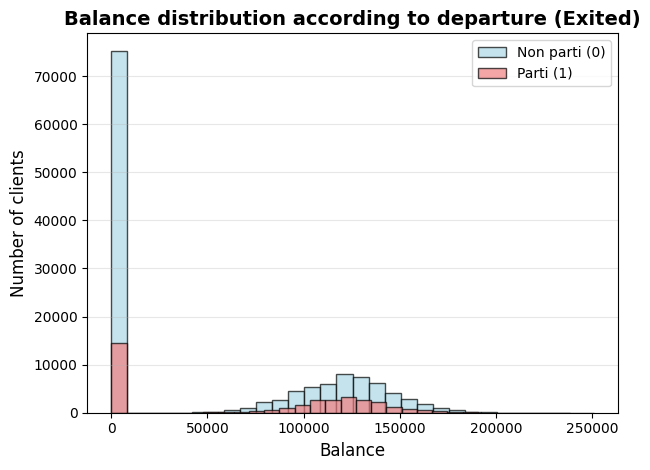

In [ ]:
plt.hist(
    df[df['Exited'] == 0]['Balance'],
    bins=30,
    alpha=0.7,
    label='Non parti (0)',
    color='lightblue',
    edgecolor='black'
)

plt.hist(
    df[df['Exited'] == 1]['Balance'],
    bins=30,
    alpha=0.7,
    label='Parti (1)',
    color='lightcoral',
    edgecolor='black'
)

plt.title('Balance distribution according to departure (Exited)', fontsize=14, fontweight='bold')
plt.xlabel('Balance', fontsize=12)
plt.ylabel('Number of clients', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

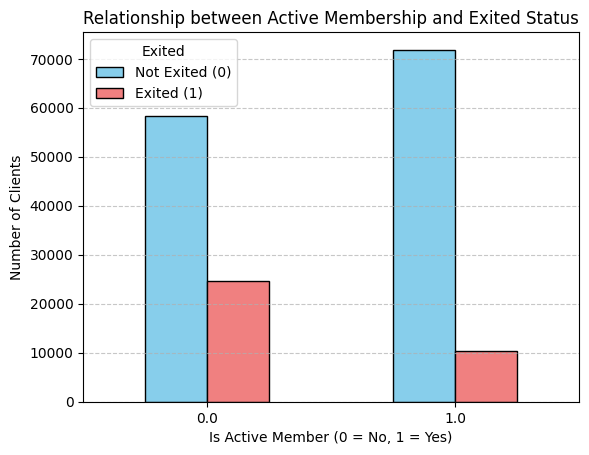

In [ ]:
active_exited = df.groupby("IsActiveMember")["Exited"].value_counts().unstack().fillna(0)

active_exited.plot(kind="bar", color=["skyblue", "lightcoral"], edgecolor="black")

plt.title("Relationship between Active Membership and Exited Status")
plt.xlabel("Is Active Member (0 = No, 1 = Yes)")
plt.ylabel("Number of Clients")
plt.legend(["Not Exited (0)", "Exited (1)"], title="Exited")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()


## 6. Correlation analysis

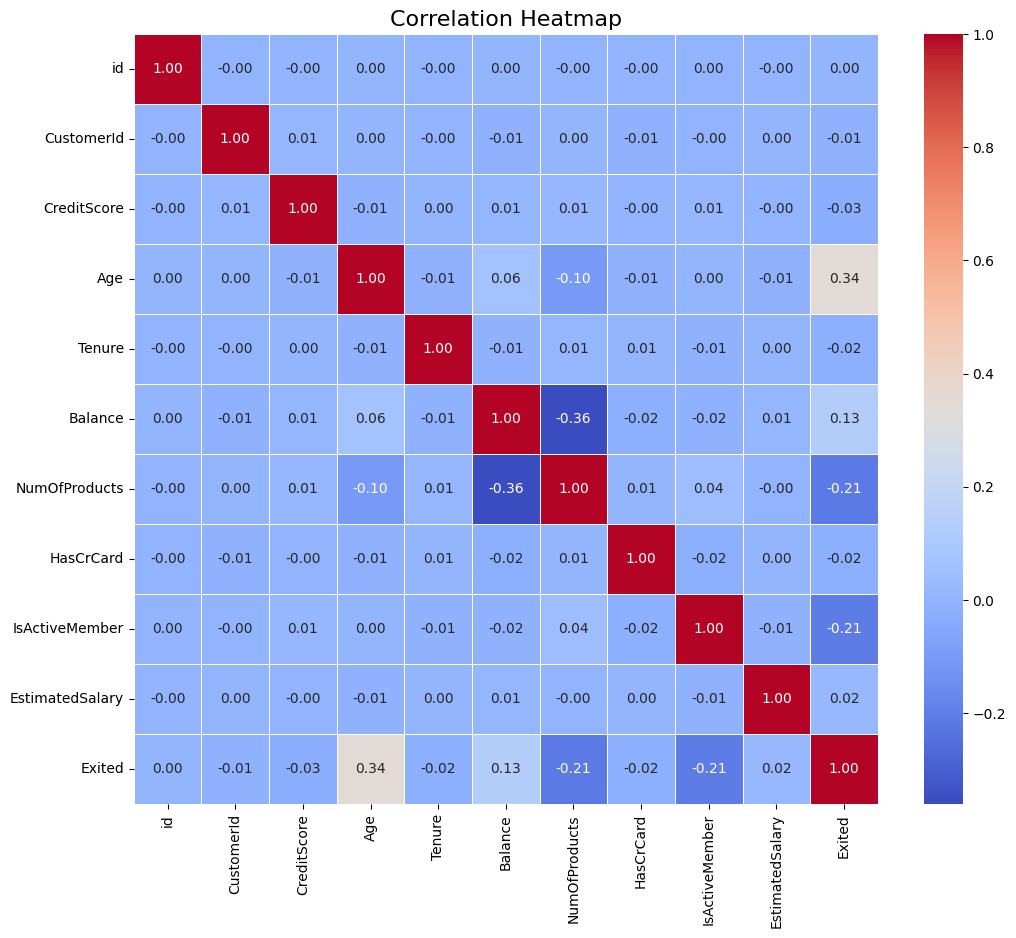

In [ ]:
target_col = 'Exited'

numerical_columns = df.select_dtypes(include=['int64', 'float64'])

correlations = numerical_columns.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    correlations,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=.5,
    cbar=True
)
plt.title('Correlation Heatmap', fontsize=16)
plt.show()

In [ ]:
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
print(correlation_matrix['Exited'].abs().sort_values(ascending=False))

Exited             1.000000
Age                0.340768
NumOfProducts      0.214554
IsActiveMember     0.210237
Balance            0.129743
CreditScore        0.027383
HasCrCard          0.022141
Tenure             0.019565
EstimatedSalary    0.018827
CustomerId         0.009947
id                 0.002512
Name: Exited, dtype: float64


## 7. Data balance

In [ ]:
class_counts = df['Exited'].value_counts()
print("Class distribution:\n", class_counts)

minority = class_counts.min()
majority = class_counts.max()
ratio = majority / minority
print(f"Imbalance ratio ≈ 1:{ratio:.2f}")

Class distribution:
 Exited
0    130113
1     34921
Name: count, dtype: int64
Imbalance ratio ≈ 1:3.73


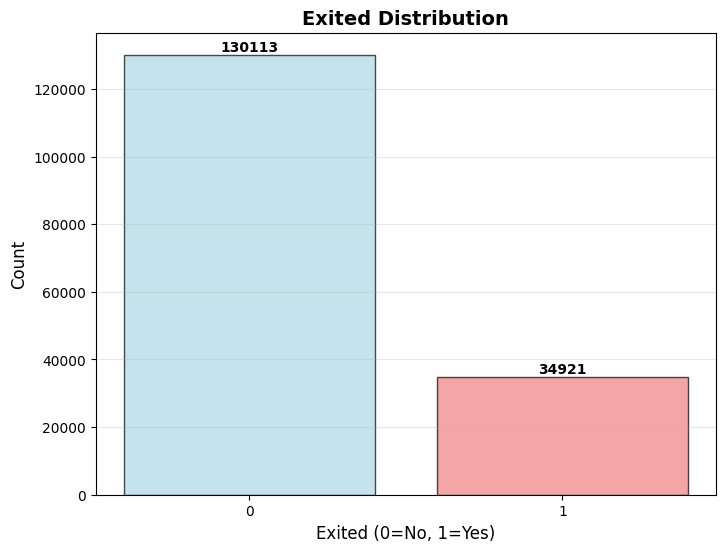

Exited rate: 21.2%


In [ ]:
# Target variable distribution
plt.figure(figsize=(8, 6))
inactive_counts = df['Exited'].value_counts()
colors = ['lightblue', 'lightcoral']
plt.bar(inactive_counts.index, inactive_counts.values, color=colors, alpha=0.7, edgecolor='black')
plt.title('Exited Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Exited (0=No, 1=Yes)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks([0, 1])
for i, v in enumerate(inactive_counts.values):
    plt.text(i, v + 10, str(v), ha='center', va='bottom', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Exited rate: {inactive_counts[1] / len(df) * 100:.1f}%")

This imbalance is not extreme (an extreme imbalance is generally around 1:10, as in fraud detection). However, it is significant enough to require specific attention, because:

- Model Bias: A default model could achieve an Accuracy of 79.5% by simply predicting that no one will inactive. It might completely ignore the minority class, which is unacceptable for a inactive prediction objective.

- Business Objective: The minority class (exited) is the main class of interest (the one the company wants to predict and prevent). Our model must excel at correctly identifying these at-risk users.

**To fix this problem, we are going to use the SMOTE later**

# III. Data pre-processing

## 1. Missing values

In [ ]:
missing_values = df.isnull().sum()
print(missing_values)

id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
AgeGroup           0
dtype: int64


In [ ]:
df_clean = df.dropna()

print(f"Original size: {len(df)}")
print(f"Size cleaned: {len(df_clean)}")
print(f"Deleted lines: {len(df) - len(df_clean)}")

Original size: 165034
Size cleaned: 165034
Deleted lines: 0


## 2. Duplicates

In [ ]:
if df_clean.duplicated().sum() > 0:
    print(df_clean[df_clean.duplicated(keep=False)])
    print(f"Duplicate rows found: {df.duplicated().sum()}")
else:
    print(" No duplicate rows found")

 No duplicate rows found


In [ ]:
id_cols = ['RowNumber', 'CustomerId', 'Surname']

feature_cols = [col for col in df_clean.columns if col not in id_cols]

duplicates = df_clean.duplicated(subset=feature_cols).sum()

if duplicates > 0:
    print(f"Duplicate entries found: {duplicates}")

    df_final = df_clean.drop_duplicates(subset=feature_cols, keep='first')

    print(f"Size before deletion: {len(df_clean)}")
    print(f"Size after deletion: {len(df_final)}")

else:
    print("No duplicate entries found.")
    df_final = df_clean.copy()

No duplicate entries found.


In [ ]:
df = df_clean

## 3. Inconsistencies

In [ ]:
print("Unique values ​​for 'Geography':")
print(df['Geography'].unique())

print("\nUnique values ​​for 'Gender':")
print(df['Gender'].unique())

Unique values ​​for 'Geography':
['France' 'Spain' 'Germany']

Unique values ​​for 'Gender':
['Male' 'Female']


No Inconsistencies here, and we didn't saw any other since the beginning of the work

## 4. Feature Engineering

**Let's create some new interesting features**  
This was not asked in the instructions but it can be really helpful to help our future models to understand better the datas and improve our results.

We clearly saw before that there are a lot of customers with a 0 balance

In [ ]:
balance_zero = df[df['Balance'] == 0]
print(f"\nNumber of customers with a balance of 0: {len(balance_zero)}")

if len(balance_zero) > 0:
    churn_rate_without_balance = balance_zero['Exited'].value_counts(normalize=True)
    print("Percentage of 'Exited' customers with a 0 balance:")
    # Access the percentage for 'Exited' (index 1) and format it
    print(f"{churn_rate_without_balance.get(1, 0):.2%}")


Number of customers with a balance of 0: 89648
Percentage of 'Exited' customers with a 0 balance:
16.17%


In [ ]:
clients_with_balance = df[df['Balance'] > 0]
churn_rate_with_balance = clients_with_balance['Exited'].mean()

print(f"'Exited' rate for customers with balance > 0: {churn_rate_with_balance:.2%}")

churn_rate_global = df['Exited'].mean()
print(f"Overall 'Exited' Rate: {churn_rate_global:.2%}")

'Exited' rate for customers with balance > 0: 27.10%
Overall 'Exited' Rate: 21.16%


In [ ]:
df_model = df.copy()

# Create a 'IsZeroBalance' feature
# 1 if the balance is 0, 0 otherwise
df_model['IsZeroBalance'] = (df_model['Balance'] == 0).astype(int)

print(df_model[['Balance', 'IsZeroBalance']].head(10))

     Balance  IsZeroBalance
0       0.00              1
1       0.00              1
2       0.00              1
3  148882.54              0
4       0.00              1
5  131778.58              0
6  144772.69              0
7  138476.41              0
8       0.00              1
9   81274.33              0


Let's say customer A and B have a tenure equal to 5 years
- Customer A (25 years old) is a very loyal customer. They have been a customer for a significant portion of their adult life.

- Customer B (60 years old) is a very recent customer. They joined you only 5 years ago, perhaps after spending 35 years with a competitor.

These two customers are radically different, but the model, simply seeing Tenure = 5, will struggle to grasp this nuance.

!!! That's what Gemini told me, we will see if this has an impact or not

In [ ]:
df_model['TenurePerAge'] = df_model['Tenure'] / (df_model['Age'] + 1) # +1 to avoid division by zero if the age is 0

- For Client A: This €100,000 balance represents two full years of their salary. It's likely their entire savings. They are extremely invested in this bank. Losing this client would be a serious loss.

- For Client B: This €100,000 balance represents only six months of their salary (or 0.5 times). For this high-income client, it might just be a temporary account or spending money. They may be less focused on the service, but also much less loyal because their main assets are elsewhere.

Unfortunately this maybe not working because the feature is an "Estimated Salary"

In [ ]:
df_model['BalancePerSalary'] = df_model['Balance'] / (df_model['EstimatedSalary'] + 1e-6) # +1e-6 to avoid division by zero if the salary is 0

In [ ]:
bins = [18, 30, 40, 50, 60, 100]
labels = ['18-29', '30-39', '40-49', '50-59', '60+']
df_model['AgeGroup'] = pd.cut(df_model['Age'], bins=bins, labels=labels, right=False)

print("\nChurn Rate by Age Group:")
print(df_model.groupby('AgeGroup')['Exited'].mean())


Churn Rate by Age Group:
AgeGroup
18-29    0.083539
30-39    0.108291
40-49    0.348000
50-59    0.609388
60+      0.349009
Name: Exited, dtype: float64


/tmp/ipython-input-3261978172.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_model.groupby('AgeGroup')['Exited'].mean())


**Let's see if our Feature Engineering worked or not**

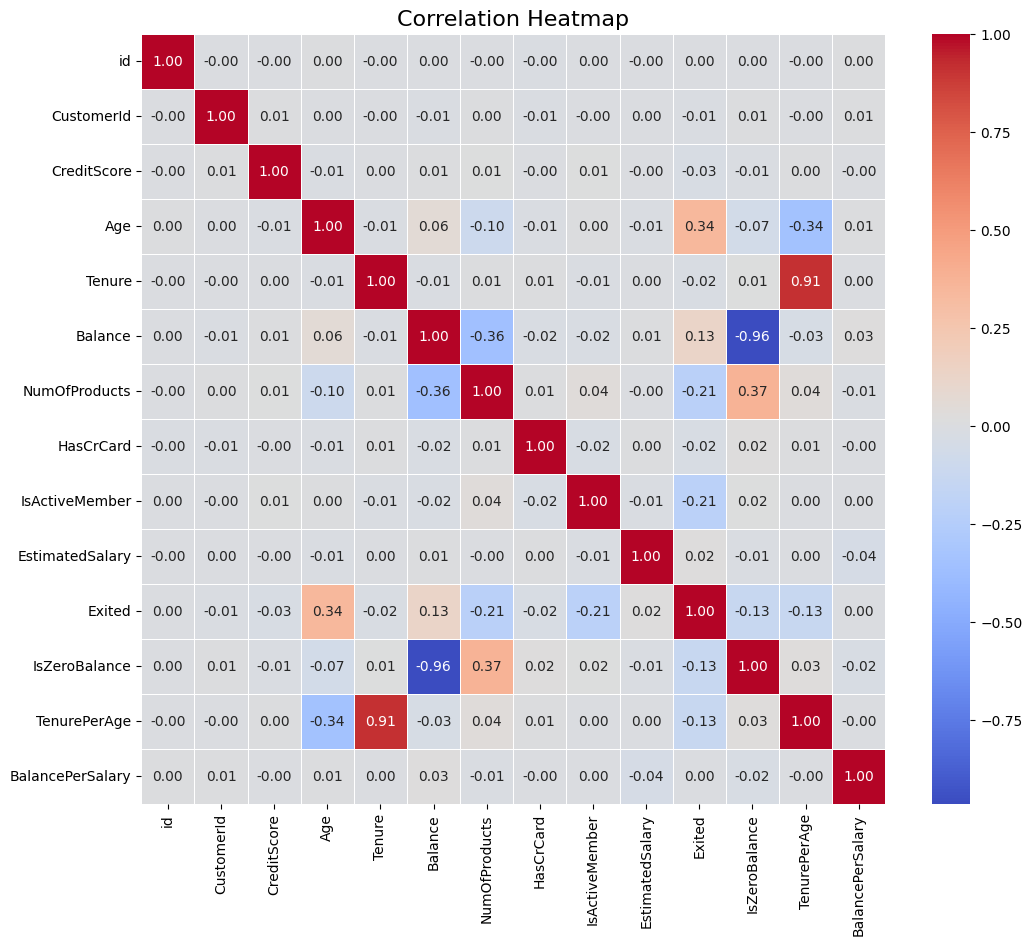

In [ ]:
target_col = 'Exited'

numerical_columns = df_model.select_dtypes(include=['int64', 'float64'])

correlations = numerical_columns.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    correlations,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=.5,
    cbar=True
)
plt.title('Correlation Heatmap', fontsize=16)
plt.show()

In [ ]:
numeric_df = df_model.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
print(correlation_matrix['Exited'].abs().sort_values(ascending=False))

Exited              1.000000
Age                 0.340768
NumOfProducts       0.214554
IsActiveMember      0.210237
IsZeroBalance       0.133346
Balance             0.129743
TenurePerAge        0.128395
CreditScore         0.027383
HasCrCard           0.022141
Tenure              0.019565
EstimatedSalary     0.018827
CustomerId          0.009947
id                  0.002512
BalancePerSalary    0.001559
Name: Exited, dtype: float64


We can see that some of our new features have a high correlation with our target feature ! Our work should help then !

In [ ]:
df = df_model

In [ ]:
df.drop(columns=['Age'], inplace=True)

## 5. Outliers

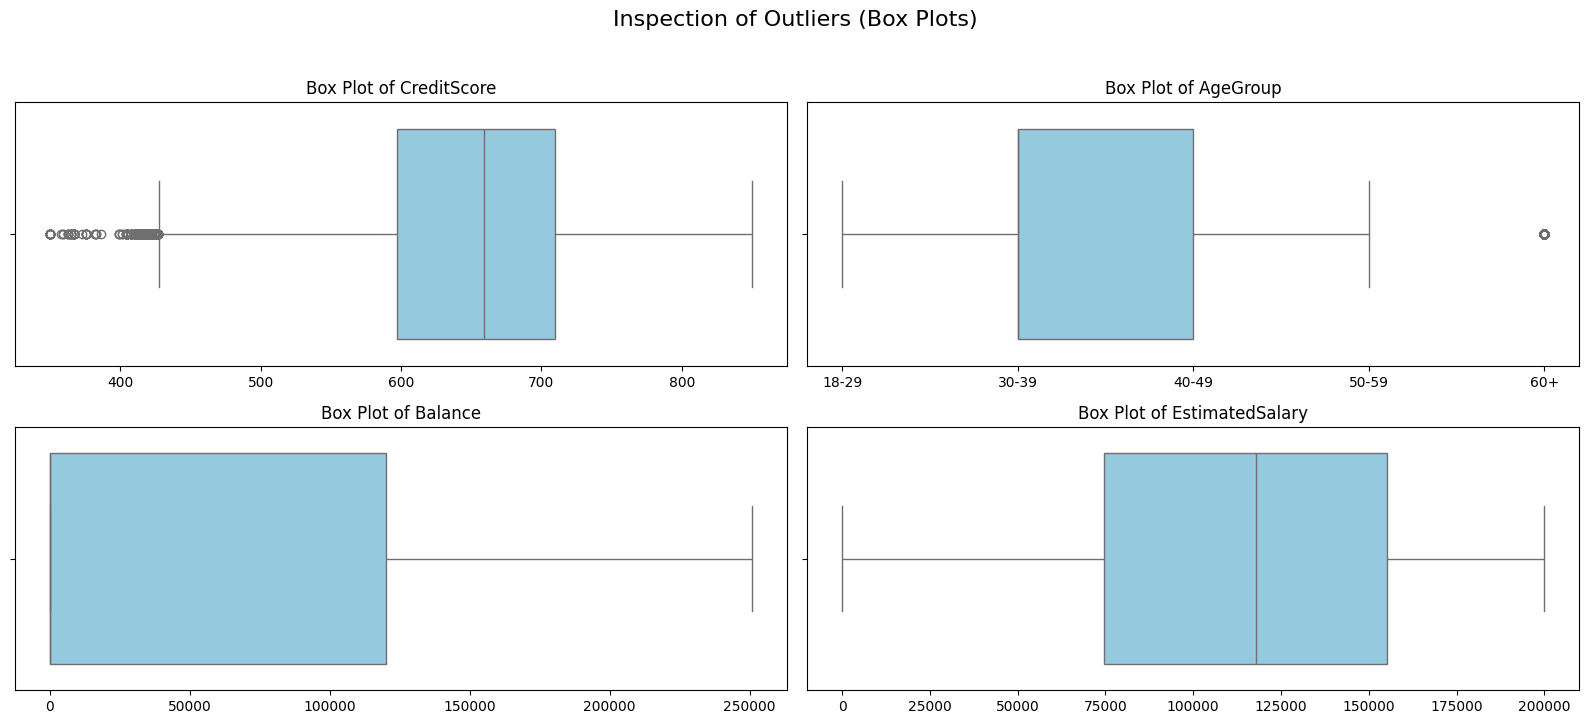

In [ ]:
cols_to_check = ['CreditScore', 'AgeGroup', 'Balance', 'EstimatedSalary']

plt.figure(figsize=(16, 10))
plt.suptitle('Inspection of Outliers (Box Plots)', fontsize=16, y=1.02)

for i, col in enumerate(cols_to_check):
    plt.subplot(3, 2, i + 1)
    sns.boxplot(x=df_model[col], color='skyblue')
    plt.title(f'Box Plot of {col}')
    plt.xlabel('')

plt.tight_layout()
plt.show()

We don't think that we need to remove the outliers because in this case the outliers are giving some insights about data.

## 6. Encoding, Scaling, Train-test-Split

In [ ]:
print(df.groupby('NumOfProducts')['Exited'].mean())

NumOfProducts
1    0.347119
2    0.060422
3    0.882516
4    0.875789
Name: Exited, dtype: float64


/tmp/ipython-input-1371081814.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['NumOfProducts'], y=df['Exited'], palette='coolwarm')


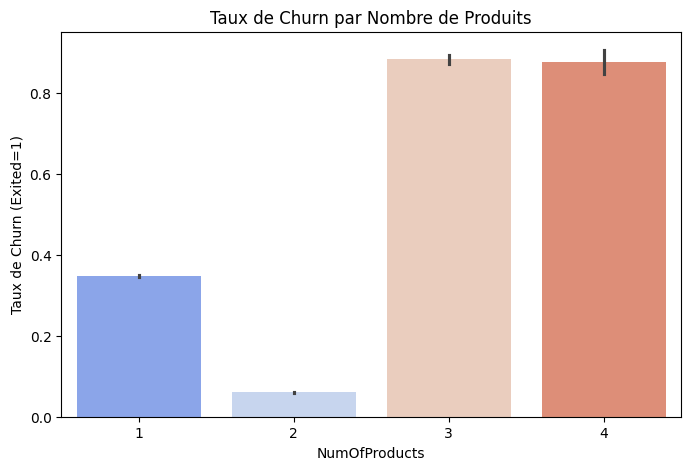

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x=df['NumOfProducts'], y=df['Exited'], palette='coolwarm')
plt.title('Taux de Churn par Nombre de Produits')
plt.ylabel('Taux de Churn (Exited=1)')
plt.show()

Here we need to use the One-Hot encoding for this features, but also for those: 'Geography', 'Gender', 'AgeGroup'

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
categorical_features = ['NumOfProducts', 'AgeGroup', 'Geography', 'Gender']
numeric_features = ['CreditScore', 'Tenure', 'Balance', 'EstimatedSalary', 'TenurePerAge', 'BalancePerSalary']

In [ ]:
y = df['Exited']
X = df.drop(columns=['Exited', 'id', 'CustomerId', 'Surname'])

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for the test
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,      # 25% of 80% = 20% of the total
    random_state=42,
    stratify=y_train_val
)

In [ ]:
# y = df['Exited']
# X = df.drop(columns=['Exited', 'RowNumber', 'CustomerId', 'Surname'])

# X_train_val, X_test, y_train_val, y_test = train_test_split(
#     X, y,
#     test_size=0.2,       # 20% for the test
#     random_state=42,
#     stratify=y
# )

# X_train, X_val, y_train, y_val = train_test_split(
#     X_train_val, y_train_val,
#     test_size=0.25,      # 25% of 80% = 20% of the total
#     random_state=42,
#     stratify=y_train_val
# )

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot',
         OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'),
         categorical_features),

        ('scale',
         StandardScaler(),
         numeric_features)
    ],
    remainder='drop'
)

In [ ]:
X_train_scaled = preprocessor.fit_transform(X_train)
X_val_scaled = preprocessor.transform(X_val)
X_test_scaled = preprocessor.transform(X_test)

encoded_feature_names = preprocessor.named_transformers_['onehot'].get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([encoded_feature_names, numeric_features])

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=all_feature_names)

In [ ]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("\nDistribution des classes APRES SMOTE (Set d'entraînement) :")
print(pd.Series(y_train_smote).value_counts())


Distribution des classes APRES SMOTE (Set d'entraînement) :
Exited
1    78067
0    78067
Name: count, dtype: int64


Here is the list of the data we can use for training:
- Original data:
  - X_train
  - y_train
- Scaled data:
  - X_train_scaled -> scaled data
  - y_train
- SMOTE data:
  - X_train_smote (scaled + SMOTE)
  - y_train_smote (SMOTE only)

Here is the list of the data we can use for validation:
- Original data:
  - X_val
  - y_val
- Scaled data:
  - X_val_scaled
  - y_val
- No SMOTE for the validation

Here is the list of the data we can use for the final test:
- Original data
  - X_test
  - y_test
- Scaled data
  - X_test_scaled
  - y_test
- No SMOTE for the test


# IV. Models

## 1. Fisrt Models

### Logistic Regression

                precision    recall  f1-score   support

Not exited (0)       0.93      0.78      0.85     26023
    Exited (1)       0.49      0.78      0.61      6984

      accuracy                           0.78     33007
     macro avg       0.71      0.78      0.73     33007
  weighted avg       0.84      0.78      0.80     33007



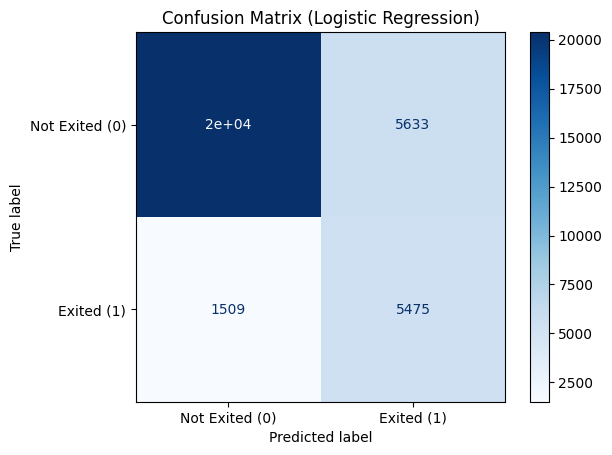

In [ ]:
model_lr = LogisticRegression(C=0.1, penalty="l2", solver="lbfgs", max_iter=1000, random_state=42)

model_lr.fit(X_train_smote, y_train_smote)

y_pred = model_lr.predict(X_val_scaled)

print(classification_report(y_val, y_pred, target_names=['Not exited (0)', 'Exited (1)']))
ConfusionMatrixDisplay.from_estimator(
    model_lr,
    X_val_scaled,
    y_val,
    display_labels=['Not Exited (0)', 'Exited (1)'],
    cmap='Blues'
)
plt.title('Confusion Matrix (Logistic Regression)')
plt.show()

### SVM (Support Vector Machine)

In [ ]:
from sklearn.svm import SVC, LinearSVC

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



 Classification Report(SVM)
                precision    recall  f1-score   support

Not Exited (0)       0.93      0.77      0.84     26023
    Exited (1)       0.48      0.80      0.60      6984

      accuracy                           0.77     33007
     macro avg       0.71      0.78      0.72     33007
  weighted avg       0.84      0.77      0.79     33007



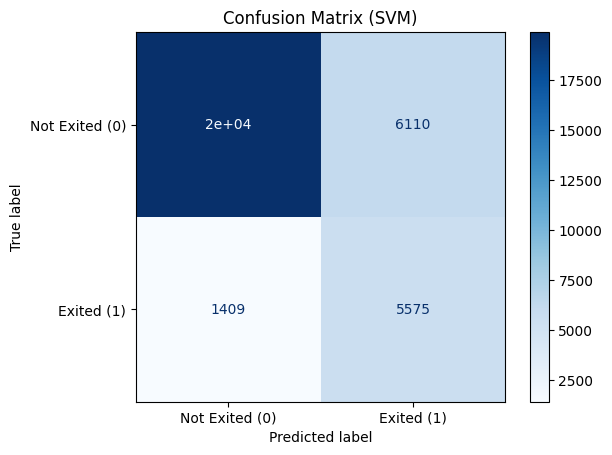

In [ ]:
model_svm = LinearSVC(C=0.1, loss="hinge", max_iter=5000, random_state=42)

model_svm.fit(X_train_smote, y_train_smote)

y_pred_svm = model_svm.predict(X_val_scaled)

print("\n Classification Report(SVM)")
print(classification_report(y_val, y_pred_svm, target_names=['Not Exited (0)', 'Exited (1)']))

ConfusionMatrixDisplay.from_estimator(
    model_svm,
    X_val_scaled,
    y_val,
    display_labels=['Not Exited (0)', 'Exited (1)'],
    cmap='Blues'
)
plt.title('Confusion Matrix (SVM)')
plt.show()

## 2. Model’s hyperparameter’s tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

### Logistic Regression

In [ ]:
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_lr = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid_lr,
    scoring='f1',
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_lr.fit(X_train_smote, y_train_smote)

print("\nBest parameters for Logistic Regression:")
print(grid_lr.best_params_)

print("\nClassification Report (Tuned LR)")
best_lr = grid_lr.best_estimator_
y_pred_lr_tuned = best_lr.predict(X_val_scaled)
print(classification_report(y_val, y_pred_lr_tuned, target_names=['Not exited (0)', 'Exited (1)']))

Fitting 5 folds for each of 6 candidates, totalling 30 fits

Best parameters for Logistic Regression:
{'C': 10}

Classification Report (Tuned LR)
                precision    recall  f1-score   support

Not exited (0)       0.93      0.78      0.85     26023
    Exited (1)       0.49      0.78      0.61      6984

      accuracy                           0.78     33007
     macro avg       0.71      0.78      0.73     33007
  weighted avg       0.84      0.78      0.80     33007



In [ ]:
param_grid_svm = {
    'C': [0.01, 0.1, 0.5, 1, 10],
    'gamma': ['scale', 1, 0.1]
}

grid_svm = GridSearchCV(
    SVC(random_state=42),
    param_grid_svm,
    scoring='f1',
    cv=5,
    verbose=3,
    n_jobs=-1
)

grid_svm.fit(X_train_smote, y_train_smote)

print("\nBest settings for the SVM:")
print(grid_svm.best_params_)

print("\nClassification Report (Tuned SVM)")
best_svm = grid_svm.best_estimator_
y_pred_svm_tuned = best_svm.predict(X_val_scaled)
print(classification_report(y_val, y_pred_svm_tuned, target_names=['Not Exited (0)', 'Exited (1)']))

Fitting 5 folds for each of 15 candidates, totalling 75 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


KeyboardInterrupt: 

Here we can see that the recall and the f1-score collapsed compared to earlier. This is due to overfitting, so let's move to the next step

# V. Obstacles

## 1. Overfitting

In [ ]:
from sklearn.metrics import f1_score

y_pred_lr_train = model_lr.predict(X_train_smote)
y_pred_lr_tuned = best_lr.predict(X_val_scaled)

f1_train = f1_score(y_train_smote, y_pred_lr_train)
f1_val = f1_score(y_val, y_pred_lr_tuned)

print(f"F1-Score (Training LR): {f1_train:.2f}")
print(f"F1-Score (Validation LR): {f1_val:.2f}")

F1-Score (Training LR): 0.79
F1-Score (Validation LR): 0.61


In [ ]:
y_pred_svm_train = model_svm.predict(X_train_smote)
y_pred_svm_tuned = model_svm.predict(X_val_scaled)

f1_train = f1_score(y_train_smote, y_pred_svm_train)
f1_val = f1_score(y_val, y_pred_svm_tuned)

print(f"F1-Score (Training SVM): {f1_train:.2f}")
print(f"F1-Score (Validation SVM): {f1_val:.2f}")

F1-Score (Training SVM): 0.79
F1-Score (Validation SVM): 0.60


We understand that both models are overfitting. Overfitting is going to be a major problem in our project. We are going to verify for each model its overfitting and try to avoid it as much as we can

Every model created in the next part will be created following the nexts steps:
1. Defining a basic model with 'classic' parameters anti-overfitting
2. Trying to optimize it, principaly with gridsearchs

## 2. Underfitting

It appears that there is no underfitting

## 3. Data Leakage

During the gridsearch the model has acces to data already transformed by SMOTE and thought he was brilliant, but he was overfitting actually

In [ ]:
from imblearn.pipeline import Pipeline

In [ ]:
from imblearn.pipeline import Pipeline as ImblearnPipeline # Ensure ImblearnPipeline is used

pipe = ImblearnPipeline([
    ('preprocessor', preprocessor), # Add the ColumnTransformer as the first step
    ('smote', SMOTE(random_state=42)),
    ('svm', SVC(random_state=42))
])

param_grid_pipe = {
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 1, 0.1]
}

grid_pipe = GridSearchCV(
    pipe,                     # We tune the entire pipeline
    param_grid_pipe,
    scoring='f1',
    cv=3,
    verbose=2,
    n_jobs=-1
)

# Pass the original X_train and X_val to the pipeline, as it now handles preprocessing internally
grid_pipe.fit(X_train, y_train)

print("\nBest settings (via Pipeline):")
print(grid_pipe.best_params_)

print("\nClassification Report (SVM via Pipeline)")
best_model_svm_pipe = grid_pipe.best_estimator_
y_pred_pipe = best_model_svm_pipe.predict(X_val)
print(classification_report(y_val, y_pred_pipe, target_names=['Not exited (0)', 'Exited (1)']))

With this pipeline we guarantee that the SMOTE is apply *inside* every training loop, which allows to avoid leakage

# VI. Relevant Metrics

**Our strategy**

The standard metrics for optimizing an imbalanced model are F-scores or Area Under the Precision-Recall Curve (PR-AUC).  
The F-beta score (a generalized F-score) is the perfect choice because it allows you to explicitly weight Recall versus Precision:
$$F_\beta = (1 + \beta^2) \cdot \frac{\text{Precision} \cdot \text{Recall}}{(\beta^2 \cdot \text{Precision}) + \text{Recall}}$$
If $\beta = 1$ (F1-score): Gives equal importance to Precision and Recall.
If $\beta < 1$ (e.g., $F_{0.5}$): Gives more weight to Precision (minimizing False Positives).  
If $\beta > 1$ (e.g., $F_{2}$): Gives more weight to Recall (minimizing False Negatives).  
Since your current model has a slightly lower Recall than a potential target, and you generally want to ensure you capture the minority class (which usually means favoring Recall), the $F_2$-score is the best choice.  
$F_2$-score places twice the weight on Recall compared to Precision, ensuring the grid search focuses on finding the positive examples.

In [ ]:
from sklearn.metrics import fbeta_score, make_scorer
from sklearn.model_selection import GridSearchCV

# Define the custom F2-scorer
# beta=2: weights Recall twice as much as Precision
# pos_label=1: explicitly targets the positive class (class 1)
f2_scorer = make_scorer(fbeta_score, beta=2, pos_label=1)

# VII. Dimension reduction

In [ ]:
df.columns

Index(['id', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited', 'AgeGroup', 'IsZeroBalance',
       'TenurePerAge', 'BalancePerSalary'],
      dtype='object')

In [ ]:
from sklearn.decomposition import PCA

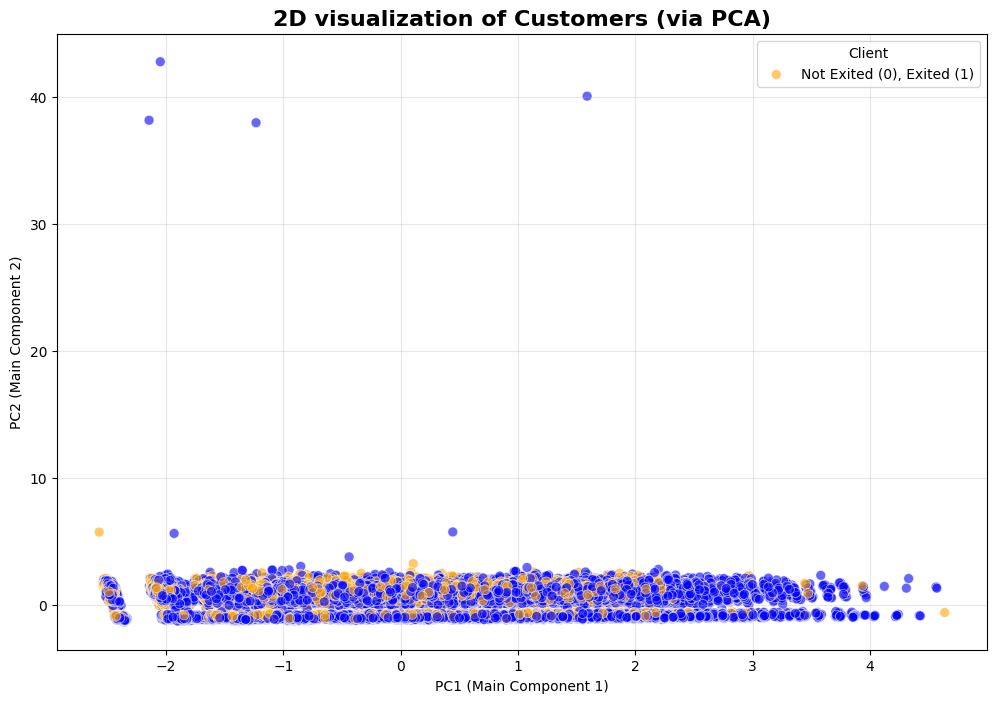

Variance explained by PC1: 26.0%
Variance explained by PC2: 15.1%
Total variance explained by 2 components: 41.1%


In [ ]:
pca_2d = PCA(n_components=2)

X_train_pca_2d = pca_2d.fit_transform(X_train_scaled)

df_pca_2d = pd.DataFrame(
    data=X_train_pca_2d,
    columns=['PC1 (Main Component 1)', 'PC2 (Main Component 2)']
)

df_pca_2d['Exited'] = y_train.values

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_pca_2d,
    x='PC1 (Main Component 1)',
    y='PC2 (Main Component 2)',
    hue='Exited',
    palette={0: 'blue', 1: 'orange'},
    alpha=0.6,
    s=50
)

plt.title('2D visualization of Customers (via PCA)', fontsize=16, fontweight='bold')
plt.legend(title='Client', labels=['Not Exited (0), Exited (1)'])
plt.grid(alpha=0.3)
plt.show()

print(f"Variance explained by PC1: {pca_2d.explained_variance_ratio_[0]:.1%}")
print(f"Variance explained by PC2: {pca_2d.explained_variance_ratio_[1]:.1%}")
print(f"Total variance explained by 2 components: {pca_2d.explained_variance_ratio_.sum():.1%}")

Here we have the visual confirmation that our problem is not linear and multi-dimensionnal (because we explane only 39.6% of the variance with a 2D PCA), and this is why our firsts models had trouble being really performant

In [ ]:
from imblearn.pipeline import Pipeline as ImblearnPipeline

In [ ]:
pipe_pca_model = ImblearnPipeline([
    ('preprocessor', preprocessor), # Added the existing ColumnTransformer
    ('pca', PCA(n_components=0.95)), # Here we reject 5% of the information
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])

pipe_pca_model.fit(X_train, y_train)

y_pred_pca = pipe_pca_model.predict(X_val)

print("\nClassification Report (PCA 95%)")
print(classification_report(y_val, y_pred_pca, target_names=['Not Exited (0)', 'Exited (1)']))
print("\nF2-Score")
print(fbeta_score(y_val, y_pred_pca, beta=2, pos_label=1))


Classification Report (PCA 95%)
                precision    recall  f1-score   support

Not Exited (0)       0.92      0.75      0.83     26023
    Exited (1)       0.45      0.75      0.56      6984

      accuracy                           0.75     33007
     macro avg       0.68      0.75      0.70     33007
  weighted avg       0.82      0.75      0.77     33007


F2-Score
0.6620658273926893


Our f1-score is lower than before. We can conclude that the 5% of the information we rejected was not noise, it was usefull information

# VIII. Advanced Models

## 1. The Tree Models
TODO: use scientific papers as reference

### Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

#### Part 1 - Simple Tree (max_depth=2)

In [ ]:
model_dt_simple = DecisionTreeClassifier(max_depth=2, random_state=42)

model_dt_simple.fit(X_train_smote, y_train_smote)

y_pred_dt_simple = model_dt_simple.predict(X_val_scaled)

print("\nClassification Report (Simple Tree, max_depth=2)")
print(classification_report(y_val, y_pred_dt_simple, target_names=['Not Exited (0)', 'Exited (1)']))
print("\nF2-Score")
print(fbeta_score(y_val, y_pred_dt_simple, beta=2, pos_label=1))


Classification Report (Simple Tree, max_depth=2)
                precision    recall  f1-score   support

Not Exited (0)       0.94      0.61      0.74     26023
    Exited (1)       0.37      0.86      0.52      6984

      accuracy                           0.66     33007
     macro avg       0.65      0.73      0.63     33007
  weighted avg       0.82      0.66      0.69     33007


F2-Score
0.6768474913964861


In [ ]:
train_score = fbeta_score(y_train_smote, model_dt_simple.predict(X_train_smote), beta=2, pos_label=1)
val_score = fbeta_score(y_val, y_pred_dt_simple, beta=2, pos_label=1)
print(f"fbeta Train : {train_score:.4f}")
print(f"fbeta Val   : {val_score:.4f}")
print(f"Gap   : {train_score - val_score:.4f}")

fbeta Train : 0.8260
fbeta Val   : 0.6768
Gap   : 0.1491


Overfitting is not too bad

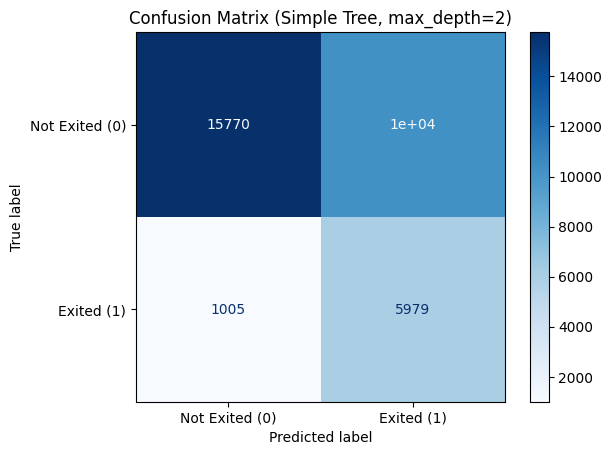

In [ ]:
ConfusionMatrixDisplay.from_estimator(
    model_dt_simple,
    X_val_scaled,
    y_val,
    display_labels=['Not Exited (0)', 'Exited (1)'],
    cmap='Blues'
)
plt.title('Confusion Matrix (Simple Tree, max_depth=2)')
plt.show()

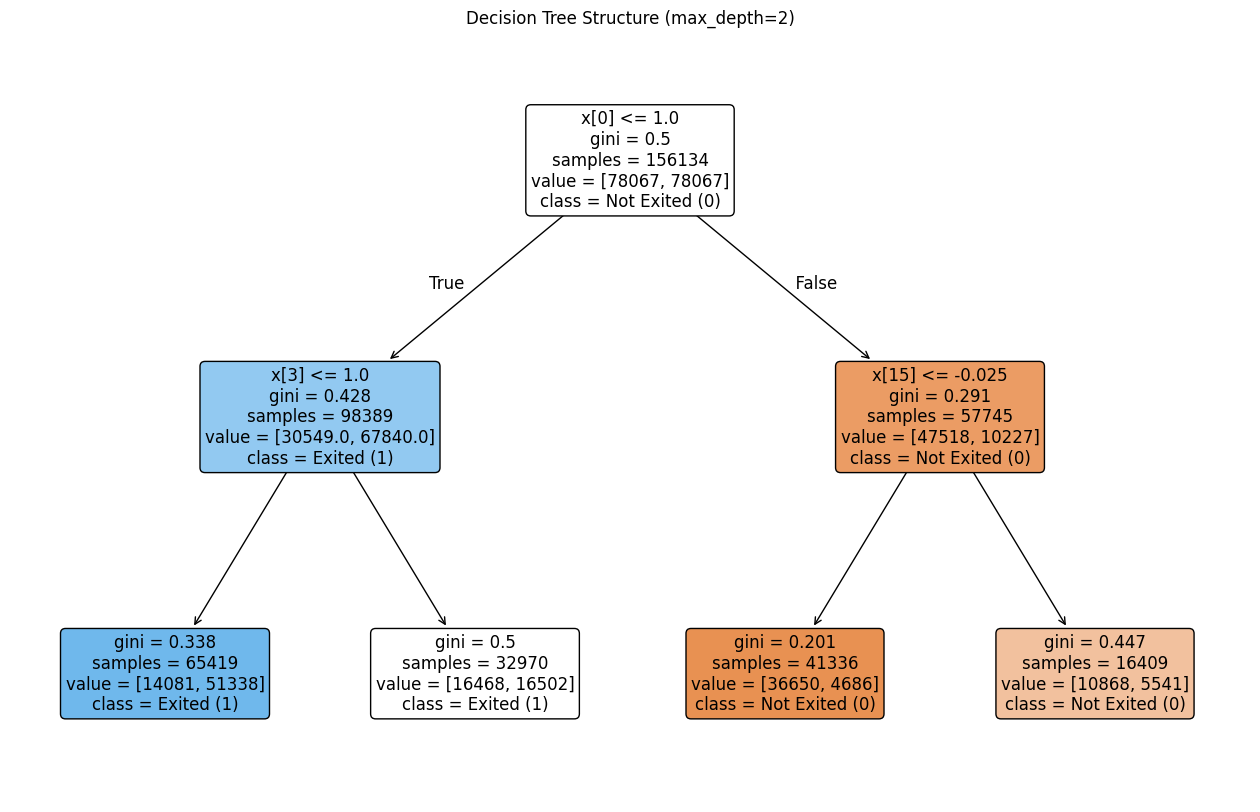

In [ ]:
plt.figure(figsize=(16, 10))
plot_tree(
    model_dt_simple,
    filled=True,
    rounded=True,
    class_names=['Not Exited (0)', 'Exited (1)'],
    fontsize=12
)
plt.title('Decision Tree Structure (max_depth=2)')
plt.show()

This very basic model catches a fair number of churners but is not very precise, flagging many clients unnecessarily.

#### Part 2 - Unlimited Depth Tree :

We now try an unlimited depth decision tree :

In [ ]:
model_dt_unlimited = DecisionTreeClassifier(random_state=42)

model_dt_unlimited.fit(X_train_smote, y_train_smote)

y_pred_dt_unlimited = model_dt_unlimited.predict(X_val_scaled)

print("\nClassification Report (Unlimited Depth Tree)")
print(classification_report(y_val, y_pred_dt_unlimited, target_names=['Not Exited (0)', 'Exited (1)']))
print("\nF2-Score")
print(fbeta_score(y_val, y_pred_dt_unlimited, beta=2, pos_label=1))


Classification Report (Unlimited Depth Tree)
                precision    recall  f1-score   support

Not Exited (0)       0.88      0.82      0.85     26023
    Exited (1)       0.46      0.57      0.51      6984

      accuracy                           0.77     33007
     macro avg       0.67      0.69      0.68     33007
  weighted avg       0.79      0.77      0.78     33007


F2-Score
0.5405849490634242


In [ ]:
train_score = fbeta_score(y_train_smote, model_dt_unlimited.predict(X_train_smote), beta=2, pos_label=1)
val_score = fbeta_score(y_val, y_pred_dt_unlimited, beta=2, pos_label=1)
print(f"fbeta Train : {train_score:.4f}")
print(f"fbeta Val   : {val_score:.4f}")
print(f"Gap   : {train_score - val_score:.4f}")

fbeta Train : 0.9991
fbeta Val   : 0.5406
Gap   : 0.4585


Huge overfitting

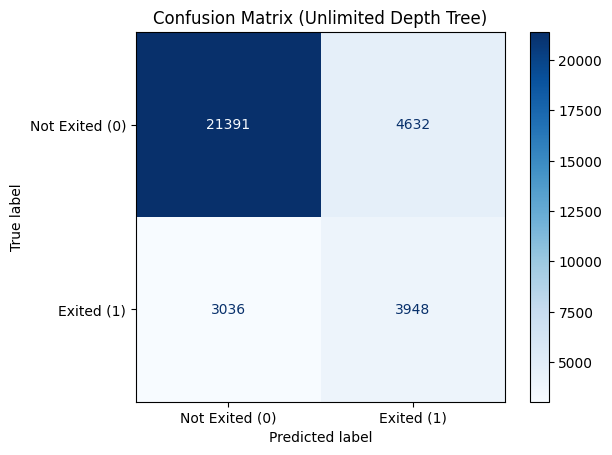

In [ ]:
ConfusionMatrixDisplay.from_estimator(
    model_dt_unlimited,
    X_val_scaled,
    y_val,
    display_labels=['Not Exited (0)', 'Exited (1)'],
    cmap='Blues'
)
plt.title('Confusion Matrix (Unlimited Depth Tree)')
plt.show()

While more flexible than the max_depth=2 tree, this model still struggles with F2-score for the churn class and shows signs of overfitting due to its unrestricted depth

#### Part 3 - Finding the Optimized Tree with GridSearchCV :

In [ ]:
param_grid = {
    'max_depth': list(range(3, 13)),
    'min_samples_leaf': list(range(5, 51, 5)),
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [10, 20, 40],
    'max_features': ['sqrt', 'log2', None]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring=f2_scorer,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_smote, y_train_smote)

print(f"\nBest parameters found: {grid_search.best_params_}")

In [ ]:
best_dt_model = grid_search.best_estimator_

y_pred_best = best_dt_model.predict(X_val_scaled)

print("\nClassification Report (Optimized Tree)")
print(classification_report(y_val, y_pred_best, target_names=['Not Exited (0)', 'Exited (1)']))
print("\nF2-Score")
print(fbeta_score(y_val, y_pred_best, beta=2, pos_label=1))

In [ ]:
train_score = fbeta_score(y_train_smote, best_dt_model.predict(X_train_smote), beta=2, pos_label=1)
val_score = fbeta_score(y_val, y_pred_best, beta=2, pos_label=1)
print(f"fbeta Train : {train_score:.4f}")
print(f"fbeta Val   : {val_score:.4f}")
print(f"Gap   : {train_score - val_score:.4f}")

We can see that our model still overfitt but our overall F2-score has improve (despite the overfitting)

In [ ]:
ConfusionMatrixDisplay.from_estimator(
    best_dt_model,
    X_val_scaled,
    y_val,
    display_labels=['Not Exited (0)', 'Exited (1)'],
    cmap='Blues'
)
plt.title(f'Confusion Matrix (Optimized Tree)\nParams: {grid_search.best_params_}')
plt.show()


In [ ]:
# Plot Tree Structure (limit depth for readability)
plt.figure(figsize=(20, 12))
plot_tree(
    best_dt_model,
    filled=True,
    rounded=True,
    class_names=['Not Exited (0)', 'Exited (1)'],
    # feature_names=X_train_smote.columns, # Uncomment if available
    fontsize=8,
    max_depth=4  # Limit visualization depth to 4 for readability
)
plt.title(f"Optimized Tree Structure (Visualizing top 4 levels)\nBest Params: {grid_search.best_params_}")
plt.show()

So we will keep the best model:

In [ ]:
model_dt = best_dt_model

## 2. Ensemble models

### RandomForestClassifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=4,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42)

model_rf.fit(X_train_smote, y_train_smote)

y_pred_rf = model_rf.predict(X_val_scaled)

print("\nClassification Report (Random Forest)")
print(classification_report(y_val, y_pred_rf, target_names=['Not Exited (0)', 'Exited (1)']))
print("\nF2-Score")
print(fbeta_score(y_val, y_pred_rf, beta=2, pos_label=1))


Classification Report (Random Forest)
                precision    recall  f1-score   support

Not Exited (0)       0.93      0.79      0.85     26023
    Exited (1)       0.49      0.77      0.60      6984

      accuracy                           0.78     33007
     macro avg       0.71      0.78      0.73     33007
  weighted avg       0.84      0.78      0.80     33007


F2-Score
0.6945086556737042


In [ ]:
train_score = fbeta_score(y_train_smote, model_rf.predict(X_train_smote), beta=2, pos_label=1)
val_score = fbeta_score(y_val, y_pred_rf, beta=2, pos_label=1)
print(f"fbeta Train : {train_score:.4f}")
print(f"fbeta Val   : {val_score:.4f}")
print(f"Gap   : {train_score - val_score:.4f}")

fbeta Train : 0.8063
fbeta Val   : 0.6945
Gap   : 0.1118


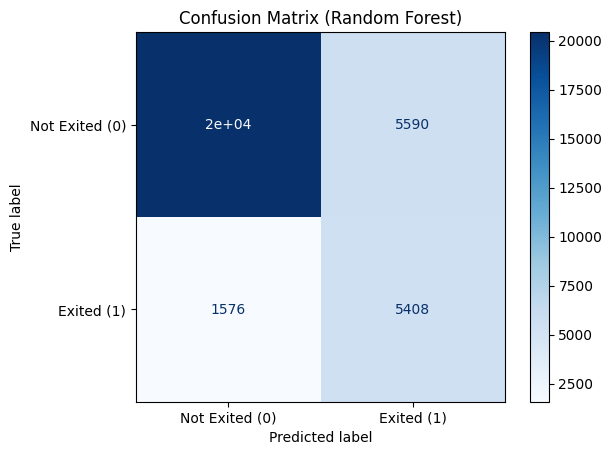

In [ ]:
ConfusionMatrixDisplay.from_estimator(
    model_rf,
    X_val_scaled,
    y_val,
    display_labels=['Not Exited (0)', 'Exited (1)'],
    cmap='Blues'
)
plt.title('Confusion Matrix (Random Forest)')
plt.show()

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=15,
    scoring=f2_scorer,
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_smote, y_train_smote)

print("Best parameters found:")
print(random_search.best_params_)


best_rf = random_search.best_estimator_
y_pred_rf = best_rf.predict(X_val_scaled)

print("\nClassification Report (Random Forest Optimized)")
print(classification_report(y_val, y_pred_rf,target_names=['Not Exited (0)', 'Exited (1)']))
print("\nF2-Score")
print(fbeta_score(y_val, y_pred_rf, beta=2, pos_label=1))

In [ ]:
train_score = fbeta_score(y_train_smote, best_rf.predict(X_train_smote), beta=2, pos_label=1)
val_score = fbeta_score(y_val, y_pred_rf, beta=2, pos_label=1)
print(f"fbeta Train : {train_score:.4f}")
print(f"fbeta Val   : {val_score:.4f}")
print(f"Gap   : {train_score - val_score:.4f}")

There is a Huge Overfitting here

In [ ]:
ConfusionMatrixDisplay.from_estimator(
    best_rf,
    X_val_scaled,
    y_val,
    display_labels=['Not Exited (0)', 'Exited (1)'],
    cmap='Blues'
)
plt.title('Confusion Matrix (Random Forest - Optimized)')
plt.show()

So the best model is the initial model:

In [ ]:
model_rf = model_rf

### XGBoost (eXtreme Gradient Boosting)

In [ ]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=42,
    eval_metric='logloss'
)

model_xgb.fit(
    X_train_smote, y_train_smote,
    eval_set=[(X_train_smote, y_train_smote), (X_val_scaled, y_val)],
    verbose=False
)

y_pred_xgb = model_xgb.predict(X_val_scaled)

print("\nClassification Report (XGBoost - Validation)")
print(classification_report(y_val, y_pred_xgb, target_names=['Not exited (0)', 'Exited (1)']))
print("\nF2-Score")
print(fbeta_score(y_val, y_pred_xgb, beta=2, pos_label=1))


Classification Report (XGBoost - Validation)
                precision    recall  f1-score   support

Not exited (0)       0.93      0.80      0.86     26023
    Exited (1)       0.51      0.76      0.61      6984

      accuracy                           0.79     33007
     macro avg       0.72      0.78      0.73     33007
  weighted avg       0.84      0.79      0.81     33007


F2-Score
0.692043324307436


In [ ]:
train_score = fbeta_score(y_train_smote, model_xgb.predict(X_train_smote), beta=2, pos_label=1)
val_score = fbeta_score(y_val, y_pred_xgb, beta=2, pos_label=1)
print(f"fbeta Train : {train_score:.4f}")
print(f"fbeta Val   : {val_score:.4f}")
print(f"Gap   : {train_score - val_score:.4f}")

fbeta Train : 0.8201
fbeta Val   : 0.6920
Gap   : 0.1281


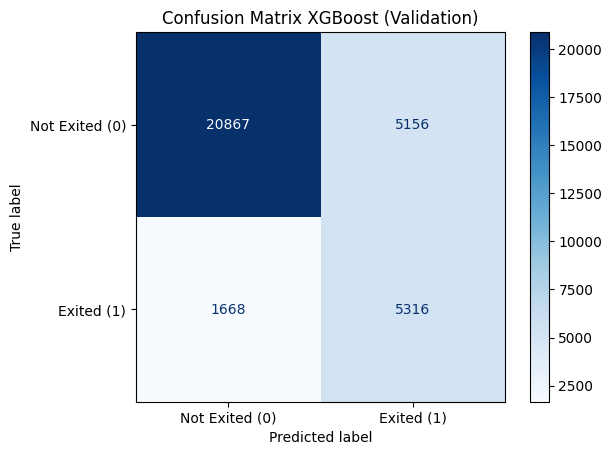

In [ ]:
ConfusionMatrixDisplay.from_estimator(
    model_xgb,
    X_val_scaled,
    y_val,
    display_labels=['Not Exited (0)', 'Exited (1)'],
    cmap='Blues'
)
plt.title('Confusion Matrix XGBoost (Validation)')
plt.show()

In [ ]:
param_grid_xgb = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'gamma': [0, 0.1, 0.5],
    'subsample': [0.8, 1.0]
}

xgb_model = XGBClassifier(
    random_state=42,
    subsample=0.8,
    eval_metric='logloss',
    use_label_encoder=False
)

grid_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    scoring=f2_scorer,
    cv=5,
    verbose=1,
    n_jobs=-1
)


grid_xgb.fit(X_train_smote, y_train_smote)

print("\Bests parameters found:")
print(grid_xgb.best_params_)

In [ ]:
best_xgb = grid_xgb.best_estimator_
y_pred_val_xgb = best_xgb.predict(X_val_scaled)

print("\nClassification Report (XGBoost Tuned - Validation)")
print(classification_report(y_val, y_pred_val_xgb, target_names=['Not exited (0)', 'Exited (1)']))
print("\nF2-Score")
print(fbeta_score(y_val, y_pred_val_xgb, beta=2, pos_label=1))

In [ ]:
train_score = fbeta_score(y_train_smote, best_xgb.predict(X_train_smote), beta=2, pos_label=1)
val_score = fbeta_score(y_val, y_pred_val_xgb, beta=2, pos_label=1)
print(f"fbeta Train : {train_score:.4f}")
print(f"fbeta Val   : {val_score:.4f}")
print(f"New Gap   : {train_score - val_score:.4f}")

It's a huge Overfitting, this optimized model is less good than the first one

So the best model is the initial one:

In [ ]:
model_xgb = model_xgb

### LightGBM (Light Gradient Boosting Machine)

In [ ]:
from lightgbm import LGBMClassifier

model_lgbm = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    num_leaves=31,
    subsample=0.8,
    random_state=42,
    n_jobs=-1,
)

model_lgbm.fit(
    X_train_smote, y_train_smote,
    eval_set=[(X_train_smote, y_train_smote), (X_val_scaled, y_val)],
    eval_metric='logloss'
)

y_pred_lgbm = model_lgbm.predict(X_val_scaled)

print("\nClassification Report (LightGBM - Validation)")
print(classification_report(y_val, y_pred_lgbm, target_names=['Not exited (0)', 'Exited (1)']))
print("\nF2-Score")
print(fbeta_score(y_val, y_pred_lgbm, beta=2, pos_label=1))

[LightGBM] [Info] Number of positive: 78067, number of negative: 78067
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015682 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3465
[LightGBM] [Info] Number of data points in the train set: 156134, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Classification Report (LightGBM - Validation)
                precision    recall  f1-score   support

Not exited (0)       0.93      0.80      0.86     26023
    Exited (1)       0.51      0.76      0.61      6984

      accuracy                           0.79     33007
     macro avg       0.72      0.78      0.73     33007
  weighted avg       0.84      0.79      0.81     33007


F2-Score
0.6894576509490458


In [ ]:
train_score = fbeta_score(y_train_smote, model_lgbm.predict(X_train_smote), beta=2, pos_label=1)
val_score = fbeta_score(y_val, y_pred_lgbm, beta=2, pos_label=1)
print(f"fbeta Train : {train_score:.4f}")
print(f"fbeta Val   : {val_score:.4f}")
print(f"Gap   : {train_score - val_score:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fbeta Train : 0.8237
fbeta Val   : 0.6895
Gap   : 0.1342


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


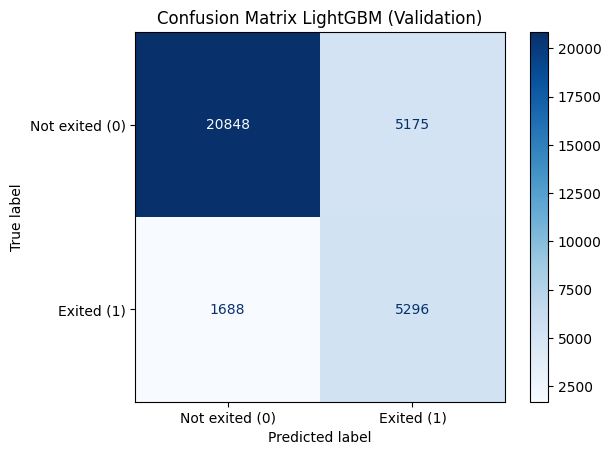

In [ ]:
ConfusionMatrixDisplay.from_estimator(
    model_lgbm,
    X_val_scaled,
    y_val,
    display_labels=['Not exited (0)', 'Exited (1)'],
    cmap='Blues'
)
plt.title('Confusion Matrix LightGBM (Validation)')
plt.show()

In [ ]:
param_grid_lgbm = {
    'num_leaves': [10, 20, 30],
    'max_depth': [3, 5, -1],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200],
    'min_child_samples': [20, 30]
}

lgbm_model = LGBMClassifier(subsample=0.8, random_state=42)

grid_lgbm = GridSearchCV(
    estimator=lgbm_model,
    param_grid=param_grid_lgbm,
    scoring=f2_scorer,
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_lgbm.fit(X_train_smote, y_train_smote)

print("\Bests parameters LightGBM:")
print(grid_lgbm.best_params_)

In [ ]:
best_lgbm = grid_lgbm.best_estimator_
y_pred_val_lgbm = best_lgbm.predict(X_val_scaled)

print("\nClassification report (LightGBM Tuné) ---")
print(classification_report(y_val, y_pred_val_lgbm, target_names=['Not exited (0)', 'Exited (1)']))
print("\nF2-Score")
print(fbeta_score(y_val, y_pred_val_lgbm, beta=2, pos_label=1))

In [ ]:
train_score = fbeta_score(y_train_smote, best_lgbm.predict(X_train_smote), beta=2, pos_label=1)
val_score = fbeta_score(y_val, y_pred_val_lgbm, beta=2, pos_label=1)
print(f"fbeta Train : {train_score:.4f}")
print(f"fbeta Val   : {val_score:.4f}")
print(f"New Gap   : {train_score - val_score:.4f}")

So the best model is the initial one:

In [ ]:
model_lgbm = model_lgbm

### VotingClassifier and StackingClassifier

#### VotingClassifier 1
First attempt using three hyperparameter-tuned models (Logistic Regression, Decision Tree, and LightGBM)

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report

best_lr = grid_lr.best_estimator_

from sklearn.tree import DecisionTreeClassifier
dt_best = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=11,
    min_samples_leaf=5,
    random_state=42
)

# 3. LightGBM modèle tuné
from lightgbm import LGBMClassifier
lgbm_best = LGBMClassifier(
    learning_rate=0.05,
    max_depth=5,
    min_child_samples=20,
    n_estimators=100,
    num_leaves=30,
    random_state=42
)

# Voting Classifier (soft voting) — le meilleur choix
voting_clf = VotingClassifier(
    estimators=[
        ('lr', best_lr),
        ('dt', dt_best),
        ('lgbm', lgbm_best)
    ],
    voting='soft',
    n_jobs=-1
)

voting_clf.fit(X_train_smote, y_train_smote)

y_pred_voting = voting_clf.predict(X_val_scaled)

print("\nVoting Classifier Report")
print(classification_report(y_val, y_pred_voting, target_names=['Not Exited (0)', 'Exited (1)']))
print("\nF2-Score")
print(fbeta_score(y_val, y_pred_voting, beta=2, pos_label=1))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Voting Classifier Report
                precision    recall  f1-score   support

Not Exited (0)       0.93      0.80      0.86     26023
    Exited (1)       0.51      0.77      0.61      6984

      accuracy                           0.79     33007
     macro avg       0.72      0.78      0.74     33007
  weighted avg       0.84      0.79      0.81     33007


F2-Score
0.695155880288099


#### StackingClassifier 1
First attempt using three hyperparameter-tuned models (Logistic Regression, Decision Tree, and LightGBM)

In [ ]:
from sklearn.ensemble import StackingClassifier

stacking_clf = StackingClassifier(
    estimators=[
        ('lr', best_lr),
        ('dt', dt_best),
        ('lgbm', lgbm_best)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    stack_method='predict_proba',
    n_jobs=-1
)

stacking_clf.fit(X_train_smote, y_train_smote)

y_pred_stack = stacking_clf.predict(X_val_scaled)

print("\nClassification Report")
print(classification_report(y_val, y_pred_stack, target_names=['Not Exited (0)', 'Exited (1)']))
print("\nF2-Score")
print(fbeta_score(y_val, y_pred_stack, beta=2, pos_label=1))

KeyboardInterrupt: 

#### VotingClassifier 2
First attempt using five hyperparameter-tuned models (Logistic Regression, Decision Tree, Random Forest,  LightGBM and SVM)

In [ ]:
best_lr = grid_lr.best_estimator_

dt_best = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=11,
    min_samples_leaf=5,
    random_state=42
)

rf_best = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='log2',
    max_depth=20,
    random_state=42
)

lgbm_best = LGBMClassifier(
    learning_rate=0.05,
    max_depth=5,
    min_child_samples=20,
    n_estimators=100,
    num_leaves=30,
    random_state=42
)

svc_best = SVC(
    kernel='rbf',
    C=1,
    gamma='scale',
    probability=True,
    random_state=42
)

voting_clf_5 = VotingClassifier(
    estimators=[
        ('lr', best_lr),
        ('dt', dt_best),
        ('rf', rf_best),
        ('lgbm', lgbm_best),
        ('svc', svc_best)
    ],
    voting='soft',
    n_jobs=-1
)

voting_clf_5.fit(X_train_smote, y_train_smote)

y_pred_voting_5 = voting_clf_5.predict(X_val_scaled)

print("\nVoting Classifier (5 models)")
print(classification_report(y_val, y_pred_voting_5, target_names=['Not Exited (0)', 'Exited (1)']))
print("\nF2-Score")
print(fbeta_score(y_val, y_pred_stack, beta=2, pos_label=1))

#### StackingClassifier 2
First attempt using five hyperparameter-tuned models (Logistic Regression, Decision Tree, Random Forest,  LightGBM and SVM)

In [ ]:
best_lr = grid_lr.best_estimator_

dt_best = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=11,
    min_samples_leaf=5,
    random_state=42
)

rf_best = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='log2',
    max_depth=20,
    random_state=42
)

lgbm_best = LGBMClassifier(
    learning_rate=0.05,
    max_depth=5,
    min_child_samples=20,
    n_estimators=100,
    num_leaves=30,
    random_state=42
)

svc_best = SVC(
    kernel='rbf',
    C=1,
    gamma='scale',
    probability=True,
    random_state=42
)

stacking_clf_5 = StackingClassifier(
    estimators=[
        ('lr', best_lr),
        ('dt', dt_best),
        ('rf', rf_best),
        ('lgbm', lgbm_best),
        ('svc', svc_best)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    stack_method='predict_proba',
    n_jobs=-1
)

stacking_clf_5.fit(X_train_smote, y_train_smote)

y_pred_stacking_5 = stacking_clf_5.predict(X_val_scaled)

print("\nClassification Report")
print(classification_report(y_val, y_pred_stacking_5, target_names=['Not Exited (0)', 'Exited (1)']))
print("\nF2-Score")
print(fbeta_score(y_val, y_pred_stacking_5, beta=2, pos_label=1))

#### VotingClassifier 3
Second attempt using three hyperparameter-tuned models (Random Forest, XGBoost and LightGBM)

In [ ]:
rf_best = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='log2',
    max_depth=20,
    random_state=42
)

xgb_best = XGBClassifier(
    gamma=0,
    learning_rate=0.1,
    max_depth=5,
    n_estimators=100,
    subsample=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

lgbm_best = LGBMClassifier(
    learning_rate=0.05,
    max_depth=5,
    min_child_samples=20,
    n_estimators=100,
    num_leaves=30,
    random_state=42
)

voting_clf_3 = VotingClassifier(
    estimators=[
        ('rf', rf_best),
        ('xgb', xgb_best),
        ('lgbm', lgbm_best)
    ],
    voting='soft',
    n_jobs=-1
)

voting_clf_3.fit(X_train_smote, y_train_smote)

y_pred_voting_3 = voting_clf_3.predict(X_val_scaled)

print("\nVoting Classifier (3 Models: RF + XGB + LGBM)")
print(classification_report(y_val, y_pred_voting_3, target_names=['Not Exited (0)', 'Exited (1)']))
print("\nF2-Score")
print(fbeta_score(y_val, y_pred_voting_3, beta=2, pos_label=1))

#### StackingClassifier 3
Second attempt using three hyperparameter-tuned models (Random Forest, XGBoost and LightGBM)

In [ ]:
rf_best = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='log2',
    max_depth=20,
    random_state=42
)

xgb_best = XGBClassifier(
    gamma=0,
    learning_rate=0.1,
    max_depth=5,
    n_estimators=100,
    subsample=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

lgbm_best = LGBMClassifier(
    learning_rate=0.05,
    max_depth=5,
    min_child_samples=20,
    n_estimators=100,
    num_leaves=30,
    random_state=42
)

stacking_clf_3 = StackingClassifier(
    estimators=[
        ('rf', rf_best),
        ('xgb', xgb_best),
        ('lgbm', lgbm_best)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    stack_method='predict_proba',
    n_jobs=-1
)

stacking_clf_3.fit(X_train_smote, y_train_smote)

y_pred_stacking_3 = stacking_clf_3.predict(X_val_scaled)

print("\nClassification Report")
print(classification_report(y_val, y_pred_stacking_3, target_names=['Not Exited (0)', 'Exited (1)']))
print("\nF2-Score")
print(fbeta_score(y_val, y_pred_stacking_3, beta=2, pos_label=1))

#### VotingClassifier 4
Third attempt using three hyperparameter-tuned models (Random Forest, XGBoost and MLP)

In [ ]:
from sklearn.neural_network import MLPClassifier

rf_best = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='log2',
    max_depth=20,
    random_state=42
)

xgb_best = XGBClassifier(
    gamma=0,
    learning_rate=0.1,
    max_depth=5,
    n_estimators=100,
    subsample=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

mlp_base = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=300,
    random_state=42
)

voting_clf_mlp = VotingClassifier(
    estimators=[
        ('rf', rf_best),
        ('xgb', xgb_best),
        ('mlp', mlp_base)
    ],
    voting='soft',
    n_jobs=-1
)

voting_clf_mlp.fit(X_train_smote, y_train_smote)

y_pred_voting_mlp = voting_clf_mlp.predict(X_val_scaled)

print("\nVoting Classifier (RF + XGB + base MLP)")
print(classification_report(y_val, y_pred_voting_mlp, target_names=['Not Exited (0)', 'Exited (1)']))
print("\nF2-Score")
print(fbeta_score(y_val, y_pred_voting_mlp, beta=2, pos_label=1))

#### StackingClassifier 4
Second attempt using three hyperparameter-tuned models (Random Forest, XGBoost and MLP)

In [ ]:
rf_best = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='log2',
    max_depth=20,
    random_state=42
)

xgb_best = XGBClassifier(
    gamma=0,
    learning_rate=0.1,
    max_depth=5,
    n_estimators=100,
    subsample=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

mlp_base = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=300,
    random_state=42
)

stacking_clf_mlp = StackingClassifier(
    estimators=[
        ('rf', rf_best),
        ('xgb', xgb_best),
        ('mlp', mlp_base)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    stack_method='predict_proba',
    n_jobs=-1
)

stacking_clf_mlp.fit(X_train_smote, y_train_smote)

y_pred_stacking_mlp = stacking_clf_mlp.predict(X_val_scaled)

print("\nClassification Report")
print(classification_report(y_val, y_pred_stacking_mlp, target_names=['Not Exited (0)', 'Exited (1)']))
print("\nF2-Score")
print(fbeta_score(y_val, y_pred_stacking_mlp, beta=2, pos_label=1))

So the best Voting Classifier is the first one and the best stacking classifier is also the first one

In [ ]:
model_vclf = voting_clf
model_scclf = stacking_clf

## 4. Neural Networks Models

### MLP (Multi Layer Perceptron)

In [ ]:
from sklearn.neural_network import MLPClassifier

model_mlp = MLPClassifier(
    random_state=42,
    max_iter=1000,
    early_stopping=True
)

model_mlp.fit(X_train_smote, y_train_smote)

y_pred_mlp = model_mlp.predict(X_val_scaled)

print("\nClassification Report (Basic MLP)")
print(classification_report(y_val, y_pred_mlp, target_names=['No exited (0)', 'Exited (1)']))
print("\nF2-Score")
print(fbeta_score(y_val, y_pred_mlp, beta=2, pos_label=1))

In [ ]:
ConfusionMatrixDisplay.from_estimator(
    model_mlp,
    X_val_scaled,
    y_val,
    display_labels=['Not exited (0)', 'Exited (1)'],
    cmap='Blues'
)
plt.title('MLP COnfusion Matrix')
plt.show()

In [ ]:
train_score = fbeta_score(y_train_smote, model_mlp.predict(X_train_smote), beta=2, pos_label=1)
val_score = fbeta_score(y_val, y_pred_mlp, beta=2, pos_label=1)
print(f"fbeta Train : {train_score:.4f}")
print(f"fbeta Val   : {val_score:.4f}")
print(f"New Gap   : {train_score - val_score:.4f}")

In [ ]:
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50, 25)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.01, 0.05],
    'learning_rate_init': [0.001, 0.01]
}

mlp = MLPClassifier(max_iter=1000, random_state=42, early_stopping=True)

grid_mlp = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid_mlp,
    scoring=f2_scorer,
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_mlp.fit(X_train_smote, y_train_smote)

print("\nBests parameters MLP:")
print(grid_mlp.best_params_)

best_mlp = grid_mlp.best_estimator_
y_pred_val_mlp = best_mlp.predict(X_val_scaled)

print("\nClassification Report (Tuned MLP)")
print(classification_report(y_val, y_pred_val_mlp, target_names=['Not exited (0)', 'Exited (1)']))
print("\nF2-Score")
print(fbeta_score(y_val, y_pred_val_mlp, beta=2, pos_label=1))

In [ ]:
train_score = fbeta_score(y_train_smote, best_mlp.predict(X_train_smote), beta=2, pos_label=1)
val_score = fbeta_score(y_val, y_pred_val_mlp, beta=2, pos_label=1)
print(f"fbeta Train : {train_score:.4f}")
print(f"fbeta Val   : {val_score:.4f}")
print(f"New Gap   : {train_score - val_score:.4f}")

So the best mlp score is the initial one

In [ ]:
model_mlp = model_mlp

# IX. Comparison

List of our models:
- Logistic Regression 1: model_lr
- SVM 1: model_svm
- Logistic Regression 2: best_lr
- SVM 2: best_svm
- SVM 3: best_model_svm_pipe
- PCA: pipe_pca_model
- Decision Tree 1: model_dt_simple
- Decision Tree 2: model_dt_unlimited
- Decision tree 3: best_dt_model
- Random Forest 1: model_rf
- Random Forest 2: best_rf
- XGBoost 1: model_xgb
- XGBoost 2: best_xgb
- LGBM 1: model_lgbm
- LGBM 2: best_lgbm
- Voting Classifier 1: voting_clf
- Voting Classifier 2: voting_clf_5
- Voting Classifier 3: voting_clf_3
- Voting Classifier 4: voting_clf_mlp
- Stacking Classifier 1: stacking_clf
- Stacking Classifier 2: stacking_clf_5
- Stacking Classifier 3: stacking_clf_3
- Stacking Classifier 4: stacking_clf_mlp
- MLP 1: model_mlp
- MLP 2: best_mlp


We chose to only represents the best model of each category

In [ ]:
all_models = {
    "Logistic Regression": model_lr,
    "SVM": model_svm,
    "PCA": pipe_pca_model,
    "Decision Tree": model_dt,
    "Random Forest": model_rf,
    "XGBoost": model_xgb,
    "LGBM": model_lgbm,
    "Voting Classifier": voting_clf,
    "Stacking Classifier": stacking_clf,
    "MLP": model_mlp
}


model_f2_scores = {}
models_with_internal_preprocessor = ["PCA"]

for name, model in all_models.items():

    if name in models_with_internal_preprocessor:
        X_input = X_val
    else:
        X_input = X_val_scaled

    try:
        y_pred_val = model.predict(X_input)

        f2_score_val = fbeta_score(
            y_val,
            y_pred_val,
            beta=2,
            pos_label=1,
        )

        model_f2_scores[name] = f2_score_val

    except Exception as e:
        print(f"Error during the computation of the F2-score for {name}: {e}")
        model_f2_scores[name] = np.nan

In [ ]:
f2_scores_df = pd.DataFrame(model_f2_scores.items(), columns=['Model', 'Test f2_scores'])
f2_scores_df = f2_scores_df.sort_values(by='Test f2_scores', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Test f2_scores', y='Model', data=f2_scores_df, palette='viridis')
plt.title('Comparison of Test f2_scores Across Models')
plt.xlabel('Test f2_scores')
plt.ylabel('Model')
plt.xlim(0.3, 1.0)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# X. Final Test on the test Data

# XI. Conclusion